# DeepSeek V4: Hyper-Connections, Lightning Indexer, and CSA

This notebook is a slow walk-through of one small idea at a time. We follow a
single token through a DeepSeek V4-style attention block, doing every
computation by hand on tiny 4-number vectors, so you can check the numbers
yourself instead of trusting a black box.

Three mechanisms, three questions:

| Mechanism | The question it answers |
|---|---|
| **Hyper-Connections (HC)** | How do we give a token several "scratch pads" of memory instead of one, without running the expensive attention/FFN block several times? |
| **Lightning Indexer (LID)** | Out of thousands of past tokens, how do we cheaply guess *which ones* are worth paying full attention to? |
| **Compressed Sparse Attention (CSA)** | Given that guess, how do we actually compute attention over only the promising positions? |

We'll build each piece up from almost nothing, run it on numbers you can
verify with a calculator, and only at the end assemble them into one block.


## Setup

Just NumPy for math and Matplotlib for pictures. Run this once.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

def softmax(x):
    """Turn a vector of scores into positive weights that sum to 1."""
    x = np.asarray(x, dtype=float)
    e = np.exp(x - np.max(x))
    return e / e.sum()

def heatmap(data, title, xlabels=None, ylabels=None, cmap='coolwarm'):
    """Draw a small labeled grid of numbers. Used throughout for 'look at this vector/matrix'."""
    data = np.atleast_2d(np.asarray(data, dtype=float))
    fig, ax = plt.subplots(figsize=(6, 2.5))
    im = ax.imshow(data, aspect='auto', cmap=cmap)
    ax.set_title(title)
    if xlabels is not None:
        ax.set_xticks(range(len(xlabels)), xlabels)
    if ylabels is not None:
        ax.set_yticks(range(len(ylabels)), ylabels)
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            ax.text(c, r, f'{data[r, c]:.2f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

print('Ready.')


Ready.


## Step 0 — One token

Everything below happens to a single token embedding: 4 numbers. In a real
model this would be a few thousand numbers; 4 is enough to see the shapes of
the computation without getting lost in a wall of digits.


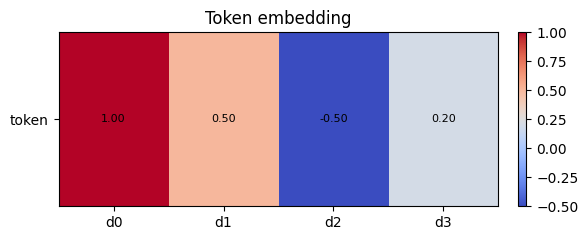

embedding: [ 1.   0.5 -0.5  0.2]


In [7]:
d_model = 4
embedding = np.array([1.0, 0.5, -0.5, 0.2])

heatmap(embedding[None, :], 'Token embedding', [f'd{i}' for i in range(d_model)], ['token'])
print('embedding:', embedding)


## Step 1 — Hyper-Connections: copy into several streams

**The problem HC solves:** a transformer normally keeps *one* residual stream
per token, and every layer reads from and writes to that same stream. That
forces very different kinds of information (syntax, long-range facts,
positional bookkeeping...) to share one pool, and layers can end up fighting
over what to write there.

**The fix:** give each token several parallel copies of its residual stream
— think of them as separate notebooks a student keeps for different subjects
— so different layers can specialize in *which* notebook they mostly read
from and write to.

At the very start of the model, before any layer has touched them, the
notebooks are all identical copies of the same embedding. Divergence only
happens once layers start writing to them differently.


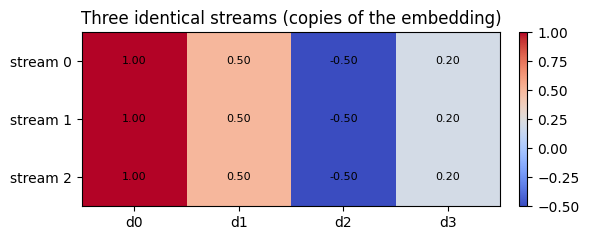

streams shape [d_model, n_streams]: (4, 3)


In [8]:
n_streams = 3
streams = np.tile(embedding[:, None], (1, n_streams))  # shape (d_model, n_streams)

heatmap(streams.T, 'Three identical streams (copies of the embedding)',
        [f'd{i}' for i in range(d_model)], [f'stream {i}' for i in range(n_streams)])
print('streams shape [d_model, n_streams]:', streams.shape)


## Step 2 — HC_PRE: merge the streams before the expensive part

Attention and the feed-forward network are expensive. HC does **not** run
them once per stream — that would multiply the cost by `n_streams` for no
reason. Instead, HC_PRE first collapses the streams down to *one* vector,
using one weight per stream. That weight is called a **gate**.

> **A gate is a learned parameter.** It is not a fixed constant anyone
> chooses by hand — during training, the model learns, per token and per
> stream, "how much should this stream count when I merge?" The number you
> see below (`pre_gates`) is only a stand-in we hand-pick for teaching, so
> you can watch what happens *after* a gate value exists, without needing an
> actual trained model to produce it.

A gate is just a single number, one per stream, that says "how much of this
stream counts when we merge." If `stream 1`'s gate is `0.9` and `stream 2`'s
gate is `0.4`, stream 1 contributes more than twice as much to the merged
result. Formula:

```
block_input = gate[0] * stream[0] + gate[1] * stream[1] + gate[2] * stream[2]
```

**How the real model produces that learned number:** take the token's
current hidden state, run it through a small learned linear layer (trained
along with everything else, via backpropagation), then squash the result
with a sigmoid — which forces it between 0 and 1 — and add a tiny epsilon so
it's never exactly 0.

The gates don't have to sum to 1 — they're independent weights, not a
probability split.

Worth noticing: because our streams are still identical copies right now,
`block_input` is just `embedding * sum(gates)` — merging clones only rescales
the vector. This stops being true once later layers make the streams differ.


gates (stand-in for a learned value): [0.9 0.4 0.7]  (sum = 2.0 , not required to sum to 1)
  after adding gate[0]=0.9 * stream 0: running total = [ 0.9   0.45 -0.45  0.18]
  after adding gate[1]=0.4 * stream 1: running total = [ 1.3   0.65 -0.65  0.26]
  after adding gate[2]=0.7 * stream 2: running total = [ 2.   1.  -1.   0.4]
block_input (same result either way): [ 2.   1.  -1.   0.4]


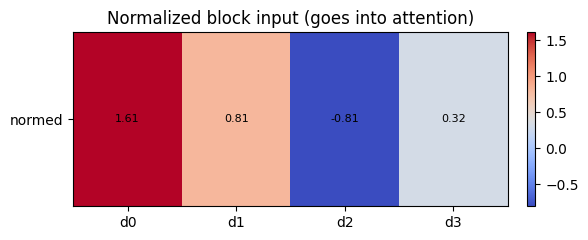

normed: [ 1.612  0.806 -0.806  0.322]


In [9]:
# pre_gates would normally be LEARNED: sigmoid(linear_layer(hidden_state)) + eps, one value per
# stream, produced fresh for every token during training. Here we hand-pick the numbers instead
# of training a model, purely so we can see what HC_PRE does with them once they exist.
pre_gates = np.array([0.9, 0.4, 0.7])
print('gates (stand-in for a learned value):', pre_gates, ' (sum =', pre_gates.sum(), ', not required to sum to 1)')

# Spelled out, so you can see exactly what's being computed:
block_input_explicit = np.zeros(d_model)
for s in range(n_streams):
    block_input_explicit += pre_gates[s] * streams[:, s]
    print(f'  after adding gate[{s}]={pre_gates[s]} * stream {s}: running total = {block_input_explicit}')

# `@` below means the exact same thing in one line: matrix-vector multiplication.
# streams has shape (d_model, n_streams); pre_gates has shape (n_streams,).
# streams @ pre_gates does, for every row d: sum over s of streams[d, s] * pre_gates[s]
# — precisely the loop above, just without writing it out.
block_input = streams @ pre_gates
assert np.allclose(block_input, block_input_explicit)
print('block_input (same result either way):', block_input)

# Sanity check on the observation above: merging identical streams just rescales.
assert np.allclose(block_input, embedding * pre_gates.sum())

def rms_norm(x, eps=1e-6):
    """Rescale a vector to have unit root-mean-square. Standard pre-attention normalization."""
    return x / np.sqrt(np.mean(x * x) + eps)

normed = rms_norm(block_input)
heatmap(normed[None, :], 'Normalized block input (goes into attention)', [f'd{i}' for i in range(d_model)], ['normed'])
print('normed:', normed)


## Step 3 — Why not just attend to everything?

Full attention compares the query against *every* past position. That's
fine for a short context, but for a long one it gets expensive fast — the
cost grows with the number of past tokens.

DeepSeek V4's answer: compress far-away history into a smaller number of
summary vectors, and use a **cheap, lightweight scorer** to guess which
summaries are worth attending to closely. That scorer is the Lightning
Indexer. It never computes the actual attention output — it only ranks
candidates, the way you might skim chapter headings before deciding which
chapters to actually read.


## Step 3 (continued) — Lightning Indexer scores compressed history

Two different sources feed this step — don't confuse them:

1. **Your one vector, `normed`** (the current token, from Step 2) gets
   projected into `index_queries` (one small query per indexer head) and
   `scalar_weights` (one signed number per head). It does **not** turn into
   the compressed keys below — it only produces the *queries* that will be
   compared against them.
2. **`compressed_keys`** are a separate set of `n_comp = 4` vectors that
   belong to *other, earlier* positions in the sequence — already-summarized
   chunks of past history, computed and cached long before this token showed
   up. In a real model these come from a compression step that pools raw
   past keys into fewer summary vectors, run once per chunk of history. In
   this notebook there's no real history to compress, so we just hand-type 4
   made-up vectors to play that role — think of them as "4 previously-written
   summary cards already sitting in a filing cabinet."

So this step is: take your query (built from the current token) and check it
against 4 *pre-existing* cards, not against anything derived from the
current token.

Each head produces its own query and its own signed weight. A candidate
card's score is a weighted sum of how well each head's query matches that
card (only positive matches count, via ReLU):

```
score[card] = sum over heads h of  weight[h] * ReLU( query[h] . key[card] )
```

We then keep only the top-K highest-scoring cards — everything else is
discarded before attention even runs.


normed (current token, from Step 2): [ 1.612  0.806 -0.806  0.322]
-> index_queries (derived from normed):
 [[ 1.289  0.081  0.161  0.097]
 [ 0.322  0.564 -0.081 -0.032]]
-> scalar_weights (derived from normed): [0.085 0.051]
compressed_keys (pre-existing, NOT derived from normed):
 [[ 1.   0.1 -0.4  0.6]
 [-0.5  0.4  0.9  0.2]
 [ 0.3 -0.7  0.1  1. ]
 [ 0.6  0.5 -0.2 -0.4]]


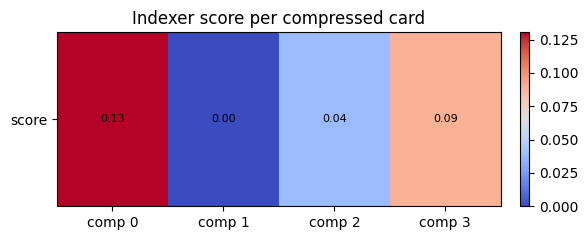

scores: [0.13  0.    0.038 0.089]
top-2 selected compressed positions: [0, 3]


In [10]:
n_heads = 2
n_comp = 4  # four compressed history "cards" to choose from

# --- Part A: pre-existing history. NOT derived from `normed` or the current token at all. ---
# In a real model these 4 vectors would already exist, produced earlier by a separate
# compression step over past tokens, and simply looked up here. We hand-type them because
# this toy example has no real sequence history to compress.
compressed_keys = np.array([
    [1.0, 0.1, -0.4, 0.6],
    [-0.5, 0.4, 0.9, 0.2],
    [0.3, -0.7, 0.1, 1.0],
    [0.6, 0.5, -0.2, -0.4],
])  # (n_comp, d_model)

# --- Part B: derived from the CURRENT token's `normed` vector from Step 2. ---
# Small hand-picked projection matrices, standing in for learned weight matrices.
index_query_proj = np.array([
    [0.8, 0.1, -0.2, 0.3],
    [0.2, 0.7, 0.1, -0.1],
])  # (n_heads, d_model)
scalar_weight_proj = np.array([
    [0.3, -0.2, 0.1, 0.0],
    [-0.1, 0.3, 0.0, 0.2],
])  # (n_heads, d_model)

index_queries = index_query_proj * normed[None, :]           # (n_heads, d_model), one query per head
scalar_weights = scalar_weight_proj @ normed / np.sqrt(d_model * n_heads)  # (n_heads,), signed

print('normed (current token, from Step 2):', normed)
print('-> index_queries (derived from normed):\n', index_queries)
print('-> scalar_weights (derived from normed):', scalar_weights)
print('compressed_keys (pre-existing, NOT derived from normed):\n', compressed_keys)

# --- Part C: compare the query (from the current token) against each pre-existing card. ---
qk = index_queries @ compressed_keys.T           # (n_heads, n_comp) raw match per head/card
contributions = scalar_weights[:, None] * np.maximum(qk, 0.0)  # ReLU, then weighted
scores = contributions.sum(axis=0)               # (n_comp,) one score per card

heatmap(scores[None, :], 'Indexer score per compressed card',
        [f'comp {p}' for p in range(n_comp)], ['score'])

k = 2
top_k_idx = np.argsort(scores)[-k:]
selected = np.zeros(n_comp, dtype=bool)
selected[top_k_idx] = True
print('scores:', scores)
print(f'top-{k} selected compressed positions:', np.flatnonzero(selected).tolist())


## Step 3.5 — Under the hood: real `nn.Module` layers, and the two axes that keep tripping people up

Everything above was written in NumPy with hand-picked numbers standing in for
learned weights. Let's rebuild the same pieces as actual PyTorch modules, so
it's obvious which numbers are **learned parameters** (trained by backprop)
and which are just **data flowing through** — and let's fix a confusing
coincidence: in the toy example, `d_model` and `n_comp` are both `4`, which
makes it look like they're related. They aren't. Below we deliberately use
different numbers for each so the two axes stay visually distinct.

**Two axes, easy to conflate, genuinely unrelated:**

| Axis | What it measures | Where it shows up | Does compression change it? |
|---|---|---|---|
| `d_model` | how many numbers describe *one* vector | every key/query/value, raw or compressed | **No** — always the same size, everywhere |
| `n_comp` / sequence length | how many *separate vectors* exist | `compressed_keys`, `selected`, `scores` | **Yes** — this is exactly what compression shrinks |

**Two separate learned modules, meeting only when the indexer runs:**

- `LightningIndexer` — owns `index_query_proj` and `scalar_weight_proj`. Turns
  *this* token's `normed` vector into a query. Trained via backprop, same as
  any other layer.
- `HistoryCompressor` — owns a completely different set of weights. Runs
  earlier, on a **block** of 32 consecutive *raw* key vectors from past
  tokens, and squashes that whole block into a single summary card of the
  same `d_model` size. This is where `compressed_keys` actually comes from —
  it is not derived from the current token at all.

**And a third, separate module for the attention step itself:**

- `CompressedSparseAttention` — owns `attn_query_proj`. Takes the *recent*
  raw positions (kept at full resolution, never compressed) together with
  whichever compressed cards the indexer selected, and attends over all of
  them at once. However many candidates go in — 6 in the earlier hand-worked
  example, 36 below (32 raw + 4 compressed) — the output is always exactly
  **one** vector of length `d_model`. Attention's job is precisely that
  collapse: many candidates in, one blended vector out.


In [11]:
import torch
import torch.nn as nn

torch.manual_seed(0)  # only for reproducible random init below -- these weights are UNTRAINED

class LightningIndexer(nn.Module):
    """
    This IS index_query_proj / scalar_weight_proj from Step 3, as a real nn.Module.
    Its weights are ordinary learned parameters, trained by backprop like any other layer.
    """
    def __init__(self, d_model, n_heads, d_index):
        super().__init__()
        self.query_proj = nn.Linear(d_model, n_heads * d_index, bias=False)
        self.weight_proj = nn.Linear(d_model, n_heads, bias=False)
        self.n_heads = n_heads
        self.d_index = d_index

    def forward(self, normed, compressed_keys):
        # normed: (d_model,)                  -- THIS token, computed right now
        # compressed_keys: (n_comp, d_index)   -- NOT a weight, passed in from elsewhere (see below)
        queries = self.query_proj(normed).view(self.n_heads, self.d_index)          # (n_heads, d_index)
        scalar_weights = self.weight_proj(normed) / (self.d_index * self.n_heads) ** 0.5  # (n_heads,)
        qk = queries @ compressed_keys.T                          # (n_heads, n_comp)
        contributions = scalar_weights.unsqueeze(1) * torch.relu(qk)
        scores = contributions.sum(dim=0)                         # (n_comp,)
        return scores


class HistoryCompressor(nn.Module):
    """
    A SEPARATE nn.Module. Runs earlier, on a block of past raw keys, not on the current token.
    Its weights are also learned, but trained to do a different job: summarize a block.
    """
    def __init__(self, d_model, block_size):
        super().__init__()
        self.compress = nn.Linear(d_model * block_size, d_model)
        self.block_size = block_size

    def forward(self, raw_key_block):
        # raw_key_block: (block_size, d_model) -- a chunk of consecutive raw keys
        return self.compress(raw_key_block.flatten())             # -> (d_model,), one summary card


# A more realistic scale than the rest of the notebook, chosen SPECIFICALLY so that
# d_model and n_comp are no longer coincidentally equal (they were both 4 above).
d_model_t = 4          # size of ONE vector -- unrelated to how many vectors exist
n_raw_history = 128    # total past tokens BEFORE any compression
block_size = 32        # how many raw tokens get folded into one summary card
n_comp_t = n_raw_history // block_size    # 128 // 32 = 4 compressed cards
n_heads_t = 2

compressor = HistoryCompressor(d_model_t, block_size)
indexer = LightningIndexer(d_model_t, n_heads_t, d_index=d_model_t)

# Pretend we have 128 raw historical key vectors, each of length d_model_t.
raw_history_keys = torch.randn(n_raw_history, d_model_t)
print('raw_history_keys shape (n_raw_history, d_model):', tuple(raw_history_keys.shape))

# Compress: split into 4 blocks of 32, run the compressor once per block.
blocks = raw_history_keys.view(n_comp_t, block_size, d_model_t)          # (4, 32, 4)
compressed_keys_t = torch.stack([compressor(block) for block in blocks])  # (4, 4)
print('compressed_keys shape (n_comp, d_model):', tuple(compressed_keys_t.shape))
print('  -> the FIRST number (n_comp) shrank from 128 raw tokens down to 4 cards.')
print('  -> the SECOND number (d_model) never changed -- still 4, same as every other vector here.')

# The current token's normalized hidden state (this is Step 2's `normed`, reused here).
normed_t = torch.tensor(normed, dtype=torch.float32)
print('normed shape (d_model,):', tuple(normed_t.shape))

scores_t = indexer(normed_t, compressed_keys_t)
print('indexer scores shape (n_comp,):', tuple(scores_t.shape), '->', scores_t.detach().numpy())

k = 2
top_k_idx_t = torch.topk(scores_t, k).indices
selected_t = torch.zeros(n_comp_t, dtype=torch.bool)
selected_t[top_k_idx_t] = True
print('selected shape (n_comp,):', tuple(selected_t.shape), '->', selected_t.tolist())


raw_history_keys shape (n_raw_history, d_model): (128, 4)
compressed_keys shape (n_comp, d_model): (4, 4)
  -> the FIRST number (n_comp) shrank from 128 raw tokens down to 4 cards.
  -> the SECOND number (d_model) never changed -- still 4, same as every other vector here.
normed shape (d_model,): (4,)
indexer scores shape (n_comp,): (4,) -> [0.097 0.105 0.186 0.069]
selected shape (n_comp,): (4,) -> [False, True, True, False]


In [12]:
class CompressedSparseAttention(nn.Module):
    """
    This IS attn_query_proj + the CSA math from Step 4, as a real nn.Module.
    A third, separate set of learned weights -- distinct from LightningIndexer's.
    """
    def __init__(self, d_model):
        super().__init__()
        self.query_proj = nn.Linear(d_model, d_model, bias=False)

    def forward(self, normed, raw_keys, raw_values, raw_available, compressed_keys, compressed_values, selected):
        query = self.query_proj(normed)                                # (d_model,)
        all_keys = torch.cat([raw_keys, compressed_keys], dim=0)        # (n_raw + n_comp, d_model)
        all_values = torch.cat([raw_values, compressed_values], dim=0)
        support = torch.cat([raw_available, selected])                  # (n_raw + n_comp,)

        logits = all_keys @ query / (query.shape[-1] ** 0.5)            # (n_raw + n_comp,)
        weights = torch.zeros(len(all_keys))
        weights[support] = torch.softmax(logits[support], dim=0)
        output = weights @ all_values                                    # (d_model,)
        return output, weights, support


csa_module = CompressedSparseAttention(d_model_t)

# 32 recent raw positions -- kept at full resolution, never sent through the compressor at all.
n_raw_recent = 32
raw_keys_t = torch.randn(n_raw_recent, d_model_t)
raw_values_t = torch.randn(n_raw_recent, d_model_t)
raw_available_t = torch.ones(n_raw_recent, dtype=torch.bool)   # all in the causal past -> all available

compressed_values_t = torch.randn(n_comp_t, d_model_t)   # stand-in; a real one comes from a value-compressor

output_t, weights_t, support_t = csa_module(
    normed_t, raw_keys_t, raw_values_t, raw_available_t,
    compressed_keys_t, compressed_values_t, selected_t,
)

print('all_keys shape:', (n_raw_recent + n_comp_t, d_model_t), ' <- this is your "32 + 4 = 36"')
print('weights shape:', tuple(weights_t.shape), ' nonzero entries:', int(support_t.sum().item()))
print('output shape (d_model,):', tuple(output_t.shape), '->', output_t.detach().numpy())
print()
print('However many candidates you start with (36 here, 6 in the earlier hand-worked demo),')
print('attention always ends by collapsing them down to ONE vector of length d_model.')


all_keys shape: (36, 4)  <- this is your "32 + 4 = 36"
weights shape: (36,)  nonzero entries: 34
output shape (d_model,): (4,) -> [-0.037  0.024 -0.004  0.182]

However many candidates you start with (36 here, 6 in the earlier hand-worked demo),
attention always ends by collapsing them down to ONE vector of length d_model.


**Recap of what just happened, mapped back to the earlier NumPy variables:**

| NumPy name (Steps 2-4) | Torch equivalent | Learned, or just data? |
|---|---|---|
| `index_query_proj`, `scalar_weight_proj` | `LightningIndexer`'s two `nn.Linear` layers | Learned — updated by backprop |
| (nothing — new in this section) | `HistoryCompressor`'s `nn.Linear` | Learned — a *different* module, trained for a different job |
| `attn_query_proj` | `CompressedSparseAttention`'s `nn.Linear` | Learned — a *third* separate module |
| `normed` | `normed_t` | Data — this token's hidden state, computed fresh right now |
| `compressed_keys` | `compressed_keys_t` | Data — but produced by `HistoryCompressor` earlier, then cached |
| `scores`, `selected` | `scores_t`, `selected_t` | Data — length `n_comp`, nothing to do with `d_model` |
| `weights`, `csa_output` | `weights_t`, `output_t` | Data — thrown away after this forward pass; not learned |

Three separate `nn.Module`s, three separate sets of weights, never sharing
parameters — they only meet by passing tensors to each other's `forward()`.
That's the whole mechanism. Everything from here on (Step 4 onward) is the
same computation, just written in the simpler hand-worked NumPy style so the
individual numbers stay easy to trace by hand.


## Step 4 — CSA: attend to what actually matters

CSA's support set has two parts:

1. **All "raw" positions the causal mask allows** — usually nearby tokens,
   kept at full resolution, no compression, no indexer involved. This is
   ordinary causal attention over the recent past.
2. **The compressed positions the Lightning Indexer selected** — the
   long-range summaries LID judged worth a closer look.

Everything else — raw positions blocked by the mask, and compressed
positions LID didn't pick — gets **exactly zero** attention weight. Sparse
attention then runs once, over just that combined support set:

```
logit[p]  = (query . key[p]) / sqrt(d_model)
weight    = softmax(logit) restricted to the support set
output    = sum over p of weight[p] * value[p]
```


In [ ]:
raw_keys = np.array([
    [0.7, -0.3, 0.8, 0.1],   # raw position 0: e.g. the previous token
    [-0.2, 0.9, 0.2, -0.8],  # raw position 1: e.g. a future token
])
raw_values = np.array([
    [0.5, -0.1, 0.8, 0.0],
    [-0.3, 0.7, 0.1, -0.6],
])
raw_available = np.array([True, False])  # the causal mask blocks position 1 (it's in the future)

compressed_values = np.array([
    [0.9, 0.2, -0.5, 0.4],
    [-0.4, 0.3, 0.7, 0.5],
    [0.2, -0.8, 0.3, 0.9],
    [0.7, 0.6, -0.3, -0.2],
])

attn_query_proj = np.array([
    [0.8, 0.1, 0.0, 0.1],
    [0.0, 0.9, 0.1, -0.1],
    [0.1, 0.0, 0.8, 0.2],
    [0.2, -0.1, 0.1, 0.8],
])
attn_query = attn_query_proj @ normed

all_keys = np.vstack([raw_keys, compressed_keys])
all_values = np.vstack([raw_values, compressed_values])
support = np.concatenate([raw_available, selected])  # True = gets attended to
labels = [f'raw {i}' for i in range(len(raw_keys))] + [f'comp {i}' for i in range(n_comp)]

logits = all_keys @ attn_query / np.sqrt(d_model)
weights = np.zeros(len(all_keys))
weights[support] = softmax(logits[support])
csa_output = weights @ all_values

heatmap(weights[None, :], 'CSA attention weights (masked/unselected are exactly 0)', labels, ['weight'])
print('support (raw mask + LID top-k):', dict(zip(labels, support)))
print('weights:', weights)
print('csa_output:', csa_output)

assert np.isclose(weights.sum(), 1.0)
assert np.all(weights[~support] == 0.0)


## Step 4.5 — Under the hood: where do `raw_keys` and `raw_values` actually come from?

Same pattern as Step 3.5. In the CSA cell above, `raw_keys` and `raw_values`
were typed in as fixed numbers. In a real model they come from two more
learned `nn.Linear` layers — usually called `W_k` and `W_v` — applied to
**every past token's own hidden state** as that token gets processed. This
is the exact mechanism from the earlier "where do keys come from?" question:
`k_t = W_k(h_t)`, computed once per token, then cached.

And CSA needs a *value* for every candidate it attends to, not just a key —
so the compressed side needs its own compressor too. `ValueCompressor` below
is the exact same idea as Step 3.5's `HistoryCompressor`, just trained to
summarize blocks of raw **values** instead of raw **keys**. Two separate
compression modules, same block-based mechanism.


In [ ]:
class KeyValueProjection(nn.Module):
    """
    W_k and W_v, as real nn.Linear layers. Applied to EVERY token's hidden state as it's
    processed, producing that token's own raw key and raw value. These get cached (the
    "KV cache") -- not recomputed on later steps.
    """
    def __init__(self, d_model):
        super().__init__()
        self.key_proj = nn.Linear(d_model, d_model, bias=False)
        self.value_proj = nn.Linear(d_model, d_model, bias=False)

    def forward(self, hidden_state):
        return self.key_proj(hidden_state), self.value_proj(hidden_state)


class ValueCompressor(nn.Module):
    """Parallel to Step 3.5's HistoryCompressor, but for values instead of keys."""
    def __init__(self, d_model, block_size):
        super().__init__()
        self.compress = nn.Linear(d_model * block_size, d_model)

    def forward(self, raw_value_block):
        return self.compress(raw_value_block.flatten())


kv_proj = KeyValueProjection(d_model_t)
value_compressor = ValueCompressor(d_model_t, block_size)

# Simulate 32 recent past tokens, each with its OWN hidden state -> its own raw key & value.
# (d_model_t, n_raw_recent, block_size, n_comp_t, normed_t, raw_available_t, compressed_keys_t,
#  selected_t, and csa_module all still exist from Step 3.5 -- reused here as-is.)
recent_hidden_states = torch.randn(n_raw_recent, d_model_t)
raw_keys_from_kv, raw_values_from_kv = kv_proj(recent_hidden_states)
print('recent_hidden_states shape (one hidden state per recent token):', tuple(recent_hidden_states.shape))
print('raw_keys_from_kv shape:', tuple(raw_keys_from_kv.shape))
print('raw_values_from_kv shape:', tuple(raw_values_from_kv.shape))

# The older, already-compressed blocks need a compressed VALUE too, not just a compressed key,
# because CSA still has to do `weight @ value` at the end.
older_value_blocks = torch.randn(n_comp_t, block_size, d_model_t)
compressed_values_from_compressor = torch.stack([value_compressor(block) for block in older_value_blocks])
print('compressed_values shape:', tuple(compressed_values_from_compressor.shape))

# Re-run Step 3.5's CSA module, now with keys/values that came from real projections
# instead of the torch.randn stand-ins used there.
output_t2, weights_t2, support_t2 = csa_module(
    normed_t, raw_keys_from_kv, raw_values_from_kv, raw_available_t,
    compressed_keys_t, compressed_values_from_compressor, selected_t,
)
print('output shape (still one vector per token, regardless of source):', tuple(output_t2.shape))


## Step 5 — HC_POST: write the result back into the streams

The block ran once and produced one output vector. HC_POST does the reverse
of HC_PRE: it routes that single result back into all the streams, mixed
with a routed version of what the streams held before.

```
new_stream[dst] = post_gate[dst] * block_output
                + sum over src of comb[dst, src] * old_stream[src]
```

`comb` is a small doubly-stochastic-ish routing matrix (each row and column
roughly sums to 1) — think of it as "how much of stream A's old content
should flow into stream B's new content." We build it with a couple of
Sinkhorn normalization passes (alternately rescaling rows and columns); the
exact derivation isn't the point here, just that it produces a soft
permutation-like mixing matrix.


In [ ]:
comb_logits = np.array([
    [2.0, 0.2, -0.4],
    [-0.3, 1.7, 0.6],
    [0.4, -0.5, 1.9],
])

def sinkhorn(logits, iters=3, eps=1e-6):
    def softmax_cols(x):
        e = np.exp(x - x.max(axis=0, keepdims=True))
        return e / e.sum(axis=0, keepdims=True)
    m = softmax_cols(logits) + eps
    m = m / (m.sum(axis=1, keepdims=True) + eps)
    for _ in range(iters - 1):
        m = m / (m.sum(axis=0, keepdims=True) + eps)
        m = m / (m.sum(axis=1, keepdims=True) + eps)
    return m

comb = sinkhorn(comb_logits, iters=3)
heatmap(comb, 'Routing matrix comb[dst, src]', [f'src {i}' for i in range(n_streams)], [f'dst {i}' for i in range(n_streams)], cmap='YlGnBu')
print('row sums (~1):', comb.sum(axis=1))
print('col sums (~1):', comb.sum(axis=0))

post_gates = np.array([0.5, 0.8, 1.1])
new_streams = (comb @ streams.T).T + post_gates[None, :] * csa_output[:, None]

heatmap(new_streams.T, 'Updated streams after HC_POST', [f'd{i}' for i in range(d_model)], [f'stream {i}' for i in range(n_streams)])
print('new_streams shape [d_model, n_streams]:', new_streams.shape)


## Step 5.5 — Under the hood: `post_gates` and `comb` are learned too

Same pattern one more time. `post_gates` and `comb_logits` in the Step 5
cell above were hand-typed numbers, exactly like `pre_gates` was back in
Step 2. In a real model, neither is a fixed constant — both are produced by
small learned `nn.Linear` layers reading the **same `normed` vector** Step 2
already produced. `normed` keeps getting reused: it fed the indexer's
queries, the attention query, and now it also feeds the routing decision for
how streams get written back.


In [ ]:
class HCPost(nn.Module):
    """
    post_gates and comb from Step 5, as real learned nn.Linear layers.
    A fourth, separate set of weights -- distinct from the indexer's, the compressor's,
    and the attention query's -- but reading the exact same `normed` input as all of them.
    """
    def __init__(self, d_model, n_streams, sinkhorn_iters=3, eps=1e-6):
        super().__init__()
        self.post_gate_proj = nn.Linear(d_model, n_streams)
        self.comb_proj = nn.Linear(d_model, n_streams * n_streams)
        self.n_streams = n_streams
        self.sinkhorn_iters = sinkhorn_iters
        self.eps = eps

    def sinkhorn(self, logits):
        m = torch.softmax(logits, dim=0) + self.eps
        m = m / (m.sum(dim=1, keepdim=True) + self.eps)
        for _ in range(self.sinkhorn_iters - 1):
            m = m / (m.sum(dim=0, keepdim=True) + self.eps)
            m = m / (m.sum(dim=1, keepdim=True) + self.eps)
        return m

    def forward(self, normed, block_output, old_streams):
        # normed: (d_model,)                  -- the SAME vector Step 2 produced, read again here
        # block_output: (d_model,)             -- CSA's single output vector for this token
        # old_streams: (d_model, n_streams)    -- the streams from BEFORE this layer
        post_gates = torch.sigmoid(self.post_gate_proj(normed)) + self.eps          # (n_streams,)
        comb_logits = self.comb_proj(normed).view(self.n_streams, self.n_streams)   # (n_streams, n_streams)
        comb = self.sinkhorn(comb_logits)
        new_streams = old_streams @ comb.T + block_output.unsqueeze(1) * post_gates.unsqueeze(0)
        return new_streams, post_gates, comb


hc_post = HCPost(d_model_t, n_streams)
streams_t = torch.tensor(streams, dtype=torch.float32)      # Step 1's streams, reused here
block_output_t = torch.tensor(csa_output, dtype=torch.float32)  # Step 4's actual csa_output, reused here

new_streams_t, post_gates_t, comb_t = hc_post(normed_t, block_output_t, streams_t)
print('post_gates shape (n_streams,):', tuple(post_gates_t.shape), '->', post_gates_t.detach().numpy())
print('comb shape (n_streams, n_streams):', tuple(comb_t.shape))
print('  row sums (~1):', comb_t.sum(dim=1).detach().numpy())
print('new_streams shape (d_model, n_streams):', tuple(new_streams_t.shape))


**Full recap: every learned module we've named, all reading from the same `normed`:**

| Module | Owns (learned weights) | Reads | Produces |
|---|---|---|---|
| HC_PRE's gate function (Step 2) | a small linear + sigmoid | the *old* streams, before merging | `pre_gates` |
| `LightningIndexer` (Step 3.5) | `query_proj`, `weight_proj` | `normed` | `index_queries`, `scalar_weights` -> `scores` |
| `HistoryCompressor` / `ValueCompressor` (Step 3.5 / 4.5) | one linear each | blocks of **past** raw keys / values | `compressed_keys`, `compressed_values` |
| `KeyValueProjection` (Step 4.5) | `key_proj`, `value_proj` | each past token's **own** hidden state | `raw_keys`, `raw_values` |
| `CompressedSparseAttention` (Step 3.5) | `query_proj` | `normed` | `attn_query` -> `csa_output` |
| `HCPost` (Step 5.5) | `post_gate_proj`, `comb_proj` | `normed` | `post_gates`, `comb` -> `new_streams` |

Six separate learned components, none sharing weights, all wired together
purely by which tensors get passed into which `forward()` call. That's the
entire mechanism this notebook has been walking through — the NumPy cells
show the arithmetic in a form you can trace by hand; these `nn.Module`
versions show where every number in that arithmetic actually comes from.


## The big picture, in plain words

Forget the shapes for a second — here's the intuition end to end.

**Fan-in, then fan-out.** You start with several streams. They get gated and
merged down into *one* vector — that's your query for this token. You take
that one vector and compare it against a pile of candidate "keys": some
recent history kept in full detail, some older history compressed into
summary cards. Comparing gives you a relevance score per candidate, softmax
turns those into weights, and you blend the candidates' values together —
many candidates collapse back into *one* output vector. That one vector then
gets spread back out across the streams it came from. Fan-in, attend,
fan-out — every layer, every token.

**The attention weights themselves are not what's learned.** Those 36 (or
whatever) softmax numbers are recomputed from scratch for every single
token, used once to blend values, then thrown away — they never persist or
accumulate. They're a *result* of the computation, not a stored parameter.

**What actually gets learned are three separate decisions, each with its
own weights:**
- **Selection** — the Lightning Indexer's job: learn which history is even
  worth attending to closely, before real attention runs.
- **Compression** — the History/Value Compressor's job: learn how to
  squash a block of old raw tokens into one useful summary, without
  losing what later layers will need.
- **Writing back** — HC_PRE and HC_POST's job: learn how much each stream
  should absorb from the merge, and how much old stream content should
  carry forward versus get overwritten.

**And those only change during training, not during any single forward
pass.** This token's output vector keeps flowing forward through the rest
of the model, all the way to a final prediction. Only once that prediction
is compared against the correct answer, far downstream, does a loss appear
— and only then does it get backpropagated through every step we've walked
through here, nudging every `nn.Linear` we've named. A single attention
step, on its own, never changes anything; it just computes and forwards.


## Step 6 — The whole pipeline, in one line

```
streams --HC_PRE--> block_input --RMSNorm--> normed
   normed --> Lightning Indexer --> top-K compressed positions
   normed --> CSA (raw mask ∪ top-K compressed) --> block_output   (attention runs ONCE)
   block_output + old streams --HC_POST--> new streams
```

The same `HC_PRE -> block -> HC_POST` wrapper is reused later around the
feed-forward/MoE sublayer — a completely separate mechanism (which *expert*
handles a token) using the identical stream-merging trick.


## What to remember

- **HC** gives each token several residual streams, but merges them to one
  vector (HC_PRE) before the expensive block runs, and routes the single
  result back out (HC_POST). The block itself never runs more than once.
- **LID** is a cheap pre-filter: it scores *compressed* history positions
  only, so the model can afford to look at a long history without paying
  full attention cost everywhere.
- **CSA** attends once, over "everything the causal mask allows nearby" plus
  "whatever LID flagged as worth a closer look" — nothing else gets weight.
